In [ ]:
import __init__

#### 1st pass finetune - Mattergen XRD
- Dataset Source: [Mattergen Alex-MP-20](https://github.com/microsoft/mattergen/tree/main/data-release/alex-mp)
  - Columns: Database (manual) 
  - Reduced Formula (Source)
  - CIF (pmg - Cifwriter with symprec 0.1)
  - XRD 'Condition Vector' (with [_calculate_theor_XRD.py](_utils/_preprocessing/_calculate_theor_XRD.py))
    - pmg - XRDCalculator(wavelength="CuKa")
    - top 20 most intense peaks selected ($2\theta$ and int)
    - Normalisations
      - $2\theta$ min-max for 0,90
      - intensities min-max for 0,100
- Deduplicated
- Cleaned for CIF augmentation
  -  Note: I didnt filter to context length here because it was not implemented yet, but filter to context was flagged as True during model training which effectively does the same thing (less efficient)
- dataset pushed to HuggingFace as: c-bone/mattergen_XRD (90:10 train/valid sets)

In [ ]:
!torchrun --nproc_per_node=2 _train.py --config '_config_files/training/conditional/xrd_studies/mattergen_XRD-slider.jsonc'

### Training
> **Note**: Here the hyperparamters change compared to regular finetuning because its 2nd pass. Backbone learning rates were set to decay from $5\times10^{-8}$ to $5\times10^{-10}$, while the learning rates for the newly initialised conditioning parameters were set 100 times higher

In [2]:
import __init__
import pandas as pd

df = pd.read_parquet('/home/cyprien/Data_Gen/chili100k_data.parquet')
# drop the 'Split' column
df = df.drop(columns=['Split'])
df.to_parquet('/home/cyprien/Data_Gen/chili100k_data.parquet', index=False)

In [4]:
!python _utils/_preprocessing/_deduplicate.py \
  --input_parquet /home/cyprien/Data_Gen/chili100k_data.parquet \
  --output_parquet HF-databases/chili100k/chili100k_dedup.parquet

Loading data from /home/cyprien/Data_Gen/chili100k_data.parquet...

Amount of entries before filtering: 20,882
Filtered down to: 20,882

Starting deduplication...
Deduplicating table CIF data...
Processing CIF entries: 100%|██████████| 20882/20882 [00:00<00:00, 29046.40it/s]
Number of entries after deduplication: 14,118

Saving deduplicated data to HF-databases/chili100k/chili100k_dedup.parquet...
Process completed successfully.


In [ ]:
df = pd.read_parquet('HF-databases/chili100k/chili100k_dedup.parquet')


# emove any cif wih partial occapncy with something like this:
# if not task_dict['include_occupancy_structures']:
#     for site in structure:
#         occ = list(site.species.as_dict().values())[0]
#         if occ < 1:
#             raise Exception("Occupancy below 1.0 found")



,Material ID,Database,Reduced Formula,CIF
0,1532947,COD,Rb2TbF6,# generated using pymatgen\ndata_Rb2TbF6\n_sym...
1,9008377,COD,Mn4Be3Si3SO12,# generated using pymatgen\ndata_Mn4Be3Si3SO12...
2,1530788,COD,CeNi5Sn,# generated using pymatgen\ndata_CeNi5Sn\n_sym...
3,1007080,COD,KMg(PO3)3,# generated using pymatgen\ndata_KMg(PO3)3\n_s...
4,9003401,COD,LiAl(SiO3)2,# generated using pymatgen\ndata_LiAl(SiO3)2\n...
...,...,...,...,...
14113,1011087,COD,FeHO2,# generated using pymatgen\ndata_FeHO2\n_symme...
14114,1523128,COD,Li3Pb,# generated using pymatgen\ndata_Li3Pb\n_symme...
14115,9008060,COD,Hg(NCl)2,# generated using pymatgen\ndata_Hg(NCl)2\n_sy...
14116,9001514,COD,Al2SiO6,# generated using pymatgen\ndata_Al2SiO6\n_sym...


In [ ]:
!python _utils/_preprocessing/_calculate_theor_XRD.py \
    --input_parquet HF-databases/chili100k/chili100k_dedup.parquet \
    --output_parquet HF-databases/chili100k/chili100k_dedup.parquet \
    --num_workers 16

Loading database from HF-databases/chili100k/chili100k_dedup.parquet
Loaded 14118 entries
Processing XRD patterns for the entries
Generating XRD patterns: 100%|███| 14118/14118 [01:26<00:00, 163.89structures/s]
Computing condition vectors from XRD patterns
Computing condition vectors: 100%|█| 14118/14118 [00:01<00:00, 14079.65structure
Theta range: 0-90, Intensity range: 0-100
Saving results to F-databases/chili100k/chili100k_dedup.parquet
done


In [11]:
!python _utils/_preprocessing/_cleaning.py \
    --input_parquet 'HF-databases/chili100k/chili100k_dedup.parquet' \
    --output_parquet 'HF-databases/chili100k/chili100k_clean.parquet' \
    --num_workers 24 \
    --add_split_column \
    --test_size 0.1 \
    --valid_size 0.1 \
    --context_length 2048 \
    # --xtra_augment

Loading data from HF-databases/chili100k/chili100k_dedup.parquet as Parquet with zstd compression...

Assigning Split column

Processing 14118 CIFs with 24 workers

Context length: 2048 (token counting enabled, variants above threshold will be blanked)

Tokenizer validation passed: token vocabulary is consistent.
Tokenizer validation passed: token vocabulary is consistent.
Tokenizer validation passed: token vocabulary is consistent.
Tokenizer validation passed: token vocabulary is consistent.
Tokenizer validation passed: token vocabulary is consistent.
Tokenizer validation passed: token vocabulary is consistent.
Tokenizer validation passed: token vocabulary is consistent.
Tokenizer validation passed: token vocabulary is consistent.
Tokenizer validation passed: token vocabulary is consistent.
Tokenizer validation passed: token vocabulary is consistent.
Tokenizer validation passed: token vocabulary is consistent.
Tokenizer validation passed: token vocabulary is consistent.
Tokenizer vali

In [12]:
df = pd.read_parquet('HF-databases/chili100k/chili100k_clean.parquet')
df

,Material ID,Database,Reduced Formula,CIF,condition_vector,Split,token_count
0,1532947,COD,Rb2TbF6,data_[Rb8Tb4F24]\nloop_\n _atom_type_symbol\n ...,"[0.29,0.29,0.326,0.32,0.323,0.166,0.512,0.438,...",val,445
1,9008377,COD,Mn4Be3Si3SO12,data_[Mn8Be6Si6S2O24]\nloop_\n _atom_type_symb...,"[0.296,0.523,0.523,0.458,0.385,0.973,0.973,0.9...",train,509
2,1530788,COD,CeNi5Sn,data_[Ce4Ni20Sn4]\nloop_\n _atom_type_symbol\n...,"[0.407,0.457,0.383,0.513,0.476,0.426,0.866,0.5...",train,513
3,1007080,COD,KMg(PO3)3,data_[K2Mg2P6O18]\nloop_\n _atom_type_symbol\n...,"[0.266,0.364,0.317,0.347,0.202,0.476,0.632,0.5...",train,479
4,9003401,COD,LiAl(SiO3)2,data_[Li4Al4Si8O24]\nloop_\n _atom_type_symbol...,"[0.336,0.358,0.228,0.432,0.314,0.299,0.53,0.64...",train,510
...,...,...,...,...,...,...,...
14113,1011087,COD,FeHO2,data_[Fe4H4O8]\nloop_\n _atom_type_symbol\n _a...,"[0.235,0.406,0.368,0.589,0.385,0.653,0.599,0.4...",test,409
14114,1523128,COD,Li3Pb,data_[Li12Pb4]\nloop_\n _atom_type_symbol\n _a...,"[0.256,0.5,0.296,0.423,0.67,0.69,0.764,0.956,0...",test,348
14115,9008060,COD,Hg(NCl)2,data_[Hg2N4Cl4]\nloop_\n _atom_type_symbol\n _...,"[0.171,0.243,0.243,0.299,0.346,0.346,0.462,0.4...",train,377
14116,9001514,COD,Al2SiO6,data_[Al8Si4O24]\nloop_\n _atom_type_symbol\n ...,"[0.335,0.305,0.264,0.474,0.422,0.76,0.722,0.48...",test,477


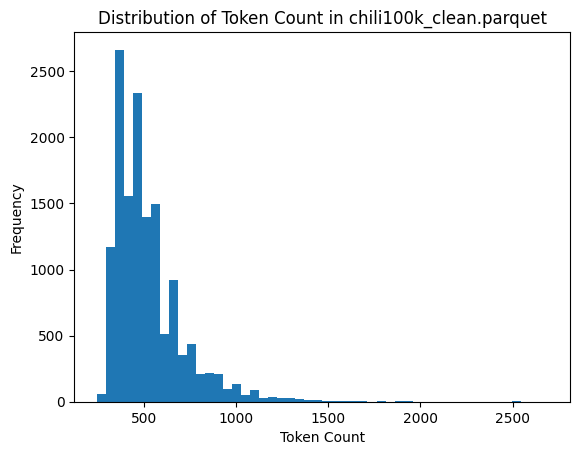

In [13]:
# print distribution of 'token_count' column as histogram plot
import matplotlib.pyplot as plt
plt.hist(df['token_count'], bins=50)
plt.xlabel('Token Count')
plt.ylabel('Frequency')
plt.title('Distribution of Token Count in chili100k_clean.parquet')
plt.show()